# Overview


IBM Telco is trying to understand why customers cancel their services and how to improve retention.

This dataset contains 7,000+ customers and 20+ variables describing customer demographics, services, billing, and churn status.

Objective: Analyze telecom customer data to monitor churn trends, identify key drivers of customer disconnections, forecast the revenue impact of churn, and build a predictive model to identify customers at high risk of leaving

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the Excel File


In [ ]:
df = pd.read_excel(r"C:\Users\dtbng\Downloads\Telco\Telco Customer Churn.xlsx")

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# Data Cleaning


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print("Columns: ",df.columns)

Columns:  Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Convert Data Types

In [ ]:
#convert to Float   
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


# Check Missing Values & Duplicates

In [ ]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
df[df['TotalCharges'].isnull()]

#TotalCharges is null when tenure is 0, so we can fill it with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering

In [ ]:
#Create tenure groups for better analysis

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, float("inf")],
    labels=["< 6 months", "6 months - 1 year", "1 - 2 years", "> 2 years"],
    right=False
)

In [ ]:
#Create a new feature for number of services subscribed 
# by counting the "Yes" values in the service columns

services = [
"PhoneService",
"MultipleLines",
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"StreamingTV",
"StreamingMovies"
]

df["ServiceCount"] = (df[services] == "Yes").sum(axis=1)

# Copy Cleaned Data

In [ ]:
#Copy the dataframe to avoid changing the original one 
# (we will add predictive features later)

df_export = df.copy()

# Standardise values

In [ ]:
# Replace Yes with 1 and No with 0
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)
df['Partner'] = df['Partner'].replace({'Yes': 1, 'No': 0}).astype(int)
df['Dependents'] = df['Dependents'].replace({'Yes': 1, 'No': 0}).astype(int)
df['PhoneService'] = df['PhoneService'].replace({'Yes': 1, 'No': 0}).astype(int)
df['PaperlessBilling'] = df['PaperlessBilling'].replace({'Yes': 1, 'No': 0}).astype(int)

In [ ]:
#Double check the changes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   int64   
 4   Dependents        7043 non-null   int64   
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   int64   
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   i

# EDA

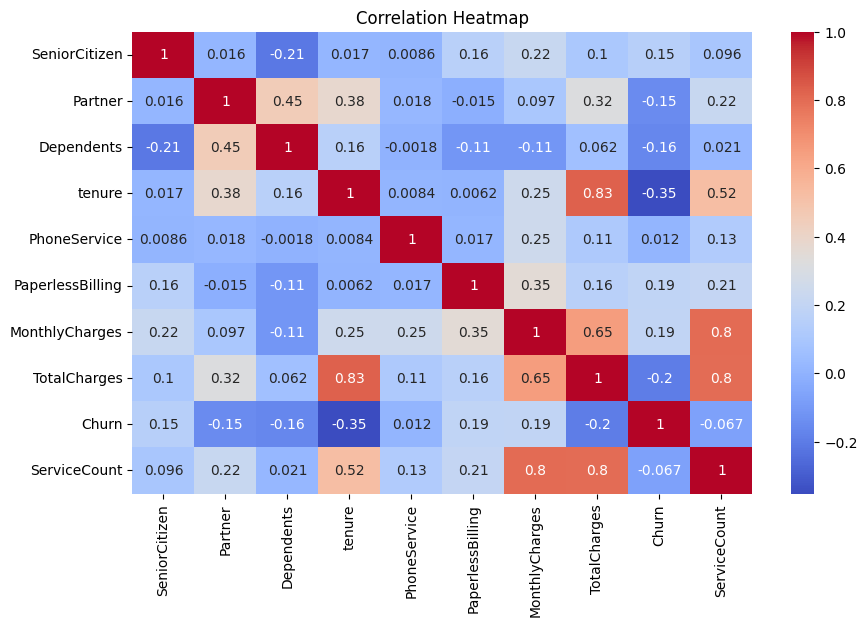

In [ ]:
#Overall correlation analysis
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insight:**
1. Tenure has the strongest relationship with churn (-0.35)
- Customers with longer tenure are much less likely to churn.New customers have the highest risk of leaving.
- Encourage customers to switch to long-term contracts. Offer discounts for 1-year contracts
- Suggestion: Loyalty incentives for new customers.Early onboarding support.

2. Customers with partners and dependents churn less ~(-0.15)
- Customers with families or dependents tend to stay longer.Single customers are more likely to cancel services.
- Family households are more stable telecom customers.
- Suggestion: Promote family bundles or shared plans

3. Higher monthly charges slightly increase churn ~(-0.19)
- Customers paying higher monthly fees are slightly more likely to leave
- Cost dissatisfaction or cheaper competitors
- Suggestion: Offer discounts or bundled services for high-paying customers.

4. Senior citizens slightly more likely to churn (0.15)
- Maybe because of Price sensitivity or Service dissatisfaction


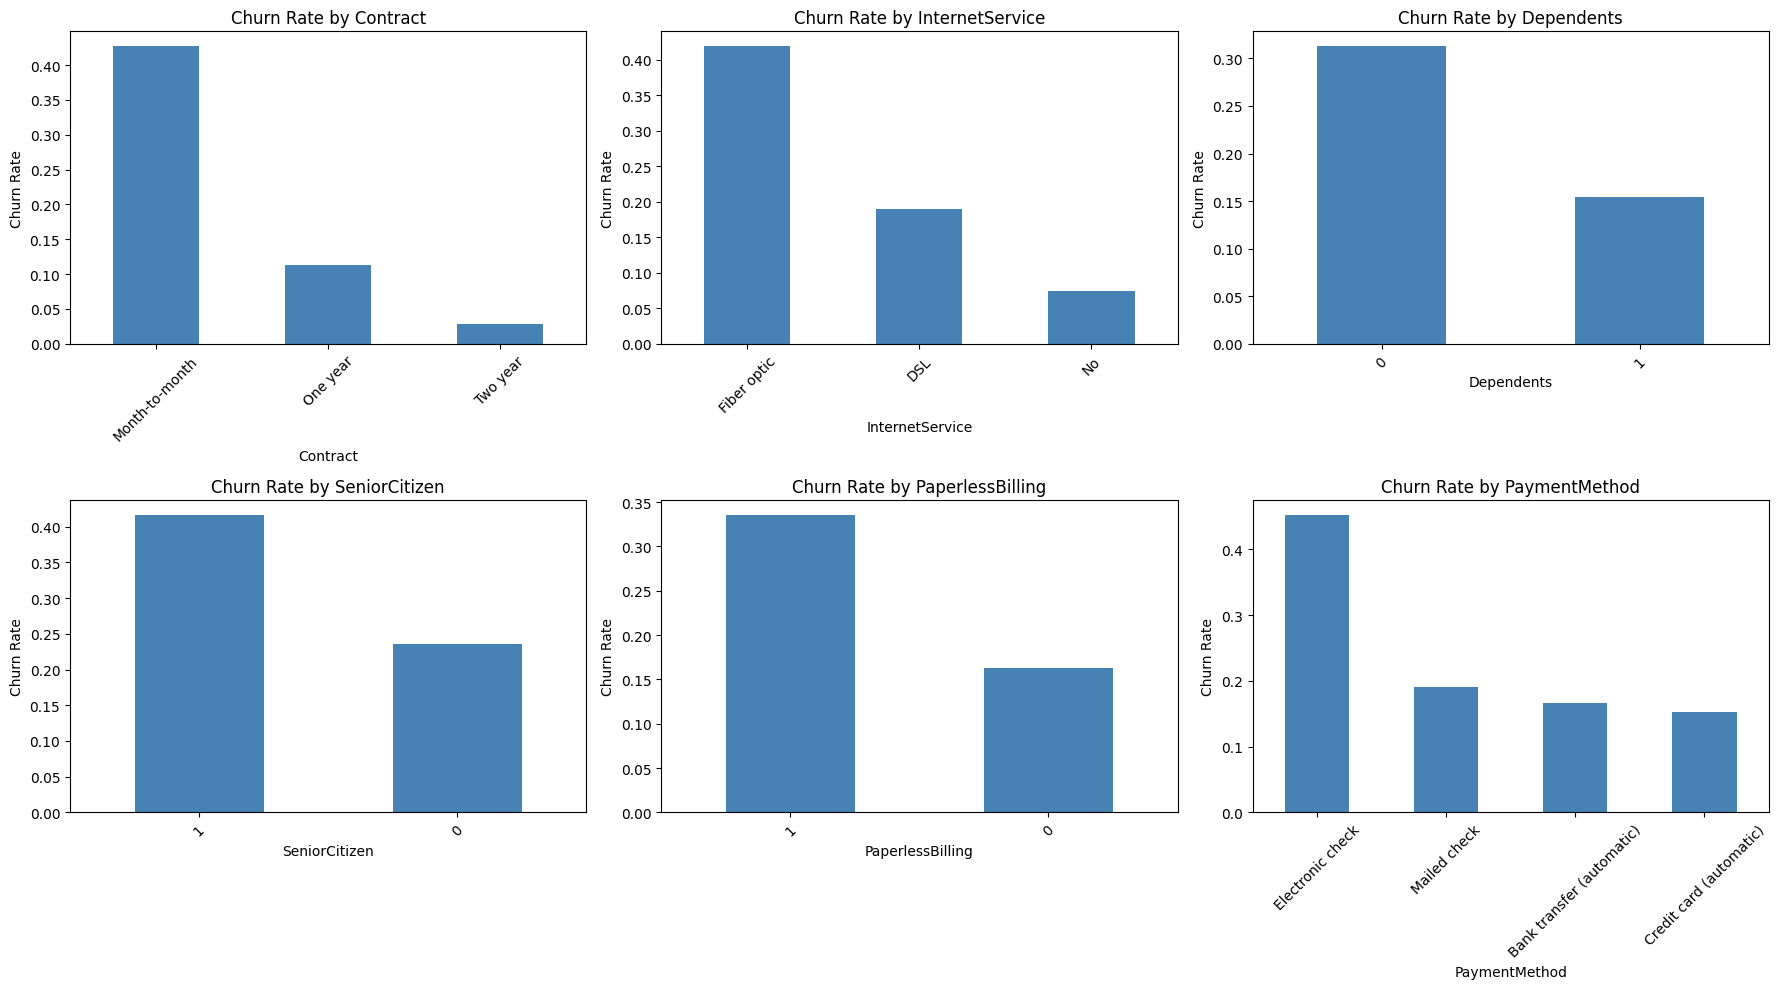

In [ ]:
#Further investigation into categorical features and their relationship with churn
features = [
    'Contract',
    'InternetService',
    'Dependents',
    'SeniorCitizen',
    'PaperlessBilling',
    'PaymentMethod'
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(features):
    
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**Conclusion**
- Contract: Month-to-month highest churn
- InternetService: Fiber often higher churn
- Dependents: Customers without dependents churn more
- SeniorCitizen: Seniors sometimes higher churn
- PaperlessBilling: Paperless customers churn more
- PaymentMethod: Electronic check highest churn

# Identify High-risk Customers

In [ ]:
df_model = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_split=4,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
churn_prob = model.predict_proba(X)[:,1]


#Add Column Churn Probability in the df_export so we can use it for predicting
df_export["ChurnProbability"] = churn_prob

In [ ]:
# Create a new column to classify customer churn risk
# By default, all customers are labeled as "Churned".
# This ensures that customers who have already churned keep this label
# and will not be included in the risk segmentation process.

df_export["RiskSegment"] = "Churned"


# Create a boolean mask to identify customers who have NOT churned.
# Only these customers will be evaluated for churn risk prediction.

mask = df_export["Churn"] == "No"


# For customers who have not churned, classify their churn probability
# into risk segments using predefined probability thresholds.
#
# The churn probability is divided into three ranges:
# 0.00 – 0.40  → Low Risk
# 0.40 – 0.70  → Medium Risk
# 0.60 – 1.00  → High Risk
#
# This segmentation helps identify customers who may churn in the future,
# enabling targeted retention strategies.

df_export.loc[mask, "RiskSegment"] = pd.cut(
    df_export.loc[mask, "ChurnProbability"],
    bins=[0, 0.4, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

In [ ]:
from sklearn.metrics import classification_report


print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.75      1409



In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

0.8222816399286986

In [ ]:
df_export.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,ChurnProbability,RiskSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,< 6 months,1,0.608035,Medium Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,> 2 years,3,0.384291,Low Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,< 6 months,3,0.566356,Churned
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,> 2 years,3,0.353513,Low Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,< 6 months,1,0.692670,Churned


In [ ]:
#Export to Excel for Power BI dashboard

df_export.to_excel("Telco_cleaned_predicted.xlsx", index=False)